In [ ]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing.image import load_img , img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.layers import Input , Dense , LSTM , Embedding , Dropout , add


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def excel_to_data(pathxy) :

  df = pd.read_excel(pathxy)

  df = df.drop(columns = "ID")

  dfx = pd.DataFrame(df.iloc[:,::2])
  dfy = pd.DataFrame(df.iloc[:,1::2])

  x_input = dfx.to_numpy()
  y_input = dfy.to_numpy()

  f_x = np.zeros((20,64))
  f_x[:x_input.shape[0],:x_input.shape[1]] = x_input

  f_y = np.zeros((20,64))
  f_y[:y_input.shape[0],:y_input.shape[1]] = y_input

  f_x = f_x.reshape((f_x.shape[0],f_x.shape[1],1))
  f_y = f_y.reshape((f_y.shape[0],f_y.shape[1],1))

  return f_x , f_y

In [ ]:
n , m , z = 20 , 64 , 1

In [ ]:
def data_pipeline(X,Y,X_OUT,Y_OUT,batch_size) :
  x = list()
  y = list()
  x_out = list()
  y_out = list()
  t = 0
  while 1:
    for i in range(len(X)):
      t+=1
      x.append(X[i])
      y.append(Y[i])
      x_out.append(X_OUT[i])
      y_out.append(Y_OUT[i])
      if t == batch_size :
        x = np.array(x)
        y = np.array(y)
        x_out = np.array(x_out)
        y_out = np.array(y_out)
        yield [x,y] ,[x_out,y_out]
        x = list()
        y = list()
        x_out = list()
        y_out = list()
        t = 0

In [ ]:
x_input = Input(shape = (n,m+2))
x_lstm = LSTM(256)(x_input)
x_output = Dense(n)(x_lstm)

y_input = Input(shape = (n,m+2))
y_lstm = LSTM(256)(y_input)
y_output = Dense(n)(y_lstm)

model = Model(inputs = [x_input , y_input] , outputs = [x_output,y_output])
model.compile(loss = "mse" , optimizer = "adam")

model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 20, 66)]             0         []                            
                                                                                                  
 input_8 (InputLayer)        [(None, 20, 66)]             0         []                            
                                                                                                  
 lstm_6 (LSTM)               (None, 256)                  330752    ['input_7[0][0]']             
                                                                                                  
 lstm_7 (LSTM)               (None, 256)                  330752    ['input_8[0][0]']             
                                                                                            

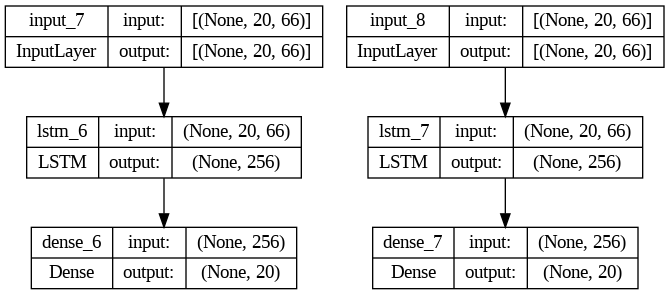

In [ ]:
plot_model(model,show_shapes = True)

In [ ]:
def convert_data(list_dir) :
  X = list()
  Y = list()
  X_OUT = list()
  Y_OUT = list()

  for i in list_dir:
    f_x , f_y = excel_to_data(f"/content/drive/MyDrive/miniproj_all_cordi/xy{i}.xlsx")

    for k in range(1):
      for j in range(1,46) :
        x_arr = np.zeros((n,m+2))
        y_arr = np.zeros((n,m+2))
        x_act = np.array(n)
        y_act = np.array(n)
        x_arr[:,0] = -1
        x_arr[:,m+1] = 2
        y_arr[:,0] = -1
        y_arr[:,m+1] = 2
        x_arr[:,1:j+1] = f_x[:,:j,k]
        y_arr[:,1:j+1] = f_y[:,:j,k]
        x_act = f_x[:,j,k]
        y_act = f_y[:,j,k]
        X.append(x_arr)
        Y.append(y_arr)
        X_OUT.append(x_act)
        Y_OUT.append(y_act)

  return X , Y , X_OUT , Y_OUT

In [ ]:
list_dir = [5,6,7,9,10]
X , Y , X_OUT , Y_OUT = convert_data(list_dir)

In [ ]:
len(X_OUT)

225

In [ ]:
def train(X,Y,X_OUT,Y_OUT,model) :

    epochs = 20
    batch_size = 32
    steps = len(X)//batch_size

    for j in range(epochs) :
      data = data_pipeline(X,Y,X_OUT,Y_OUT,batch_size)
      model.fit(data,epochs = 1,steps_per_epoch = steps,verbose = 1)


In [ ]:
train(X,Y,X_OUT,Y_OUT,model)

7/7 [==============================] - 1s 98ms/step - loss: 0.0242 - dense_6_loss: 0.0121 - dense_7_loss: 0.0121


In [ ]:
def predict(model , x_start , y_start) :
  x_input , y_input = x_start , y_start
  f_pre_x = list()
  f_pre_y = list()
  for j in range(46,51):
    x_pre , y_pre = model.predict( [x_input , y_input] , verbose = 0)
    f_pre_x.append(x_pre)
    f_pre_y.append(y_pre)
    x_input[:,:,j] = x_pre
    y_input[:,:,j] = y_pre

  return f_pre_x , f_pre_y

In [ ]:
# x_start = np.zeros((1,n,m+2))
# y_start = np.zeros((1,n,m+2))

# x_start[:,:,0] = -1
# x_start[:,:,m+1] = 2
# x_start[:,:,1] = np.random.uniform(low = 1.0 , high = 2.0, size = n)

# y_start[:,:,0] = -1
# y_start[:,:,m+1] = 3
# y_start[:,:,1] = np.random.uniform(low = 1.0, high = 2.0 ,size = n)

# x_final , y_final =  predict(model,x_start , y_start)

# x_final = x_final.reshape((x_final.shape[1],x_final.shape[2]))
# y_final = y_final.reshape((y_final.shape[1],y_final.shape[2]))


In [ ]:
# x_final = pd.DataFrame(x_final)
# y_final = pd.DataFrame(y_final)

In [ ]:
# x_final.head()

In [ ]:
# act_x , act_y = excel_to_data(f"/content/drive/MyDrive/miniproj_all_cordi/xy10.xlsx")

In [ ]:
# pre_x , pre_y = np.zeros((1,n,m+2)) ,np.zeros((1,n,m+2))
# pre_x[:,:,0] = -1
# pre_x[:,:,m+1] = 2

# pre_y[:,:,0] = -1
# pre_y[:,:,m+1] = 2

# pre_x[0,:,1:46] = act_x[:,0:45,0]
# pre_y[0,:,1:46] = act_y[:,0:45,0]

# pred_x , pred_y = predict(model,pre_x,pre_y)

# final_prediction = list()

# for i in range(len(pred_x)) :
#   final_prediction.append(pred_x[i])
#   final_prediction.append(pred_y[i])

# print(final_prediction)


In [ ]:
def final_predict(path) :
  act_x , act_y = excel_to_data(path)

  pre_x , pre_y = np.zeros((1,n,m+2)) ,np.zeros((1,n,m+2))
  pre_x[:,:,0] = -1
  pre_x[:,:,m+1] = 2

  pre_y[:,:,0] = -1
  pre_y[:,:,m+1] = 2

  pre_x[0,:,1:46] = act_x[:,0:45,0]
  pre_y[0,:,1:46] = act_y[:,0:45,0]

  pred_x , pred_y = predict(model,pre_x,pre_y)

  final_prediction = list()

  for i in range(len(pred_x)) :
    final_prediction.append(pred_x[i])
    final_prediction.append(pred_y[i])

  return final_prediction

In [ ]:
output = final_predict(f"/content/drive/MyDrive/miniproj_all_cordi/xy10.xlsx")


In [ ]:
def show_output(output) :
  output = np.array(output)
  final_output = np.zeros((output.shape[2],output.shape[0]))
  for i in range(output.shape[2]):
    final_output[i:] = output[:,0,i]

  final_output = pd.DataFrame(final_output)
  return final_output

In [ ]:
show_output(output)

,0,1,2,3,4,5,6,7,8,9
0,0.451354,0.803318,0.445934,0.819162,0.452205,0.832382,0.456957,0.861451,0.451404,0.879231
1,0.014711,-0.024442,0.011283,-0.033169,0.011136,-0.042533,0.011274,-0.027484,0.012889,-0.037772
2,0.929141,0.280980,0.936789,0.262648,0.927870,0.242453,0.924096,0.218736,0.911101,0.213284
3,0.058149,0.513097,0.065023,0.512623,0.067998,0.497268,0.071069,0.499855,0.071905,0.499646
4,-0.009071,0.010864,-0.005985,0.026772,0.007754,0.051366,0.008156,0.043066,0.005910,0.006525
5,0.920517,0.280614,0.925576,0.293067,0.926336,0.286017,0.918015,0.293329,0.904056,0.291075
6,0.777272,0.498472,0.774252,0.492874,0.769463,0.483688,0.766085,0.463574,0.755820,0.480562
7,0.004046,0.477145,0.009620,0.502113,-0.001565,0.508627,0.004634,0.488070,0.006254,0.513907
8,-0.002245,0.012918,-0.006376,0.006810,0.001279,0.025096,0.003233,0.020644,-0.001935,0.035368
9,0.777322,0.576315,0.774689,0.581836,0.769970,0.579595,0.776971,0.590594,0.778111,0.600925


In [ ]:
def calculate_error(output , label_data) :

  output = np.array(output)
  final_output = np.zeros((output.shape[2],output.shape[0]))
  for i in range(output.shape[2]):
    final_output[i:] = output[:,0,i]

  final_output = pd.DataFrame(final_output)

  error = 0.0
  for i in range(20):
    for j in range(10):
      f = final_output.iloc[i, j]
      s = label_data.iloc[i, j]

      if s != 0:
        error += (f - s) ** 2

  return error

In [ ]:
def get_label_data(path) :
  label_data_x , label_data_y = excel_to_data(path)
  label_data = np.zeros((20,10))
  for i in range(20) :
    ct = 0
    for j1, j2 in zip(range(45,50), range(45,50)):
      label_data[i][ct] = label_data_x[i][j1]
      ct+=1
      label_data[i][ct] = label_data_y[i][j2]
      ct+=1

  label_data = pd.DataFrame(label_data)
  return label_data

In [ ]:
label_data = get_label_data("/content/drive/MyDrive/miniproj_all_cordi/xy10.xlsx")

In [ ]:
label_data

,0,1,2,3,4,5,6,7,8,9
0,0.424837,0.835244,0.415500,0.840974,0.406162,0.845272,0.402428,0.848138,0.391223,0.853868
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.999066,0.280802,0.999066,0.282235,0.999066,0.282235,0.999066,0.282235,0.999066,0.283668
3,0.030812,0.514327,0.029879,0.514327,0.029879,0.514327,0.029879,0.514327,0.030812,0.514327
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.977591,0.296562,0.977591,0.296562,0.977591,0.296562,0.977591,0.296562,0.977591,0.296562
6,0.765640,0.501433,0.770308,0.500000,0.774043,0.497135,0.775910,0.495702,0.780579,0.492837
7,0.011204,0.472779,0.011204,0.474212,0.011204,0.474212,0.011204,0.474212,0.011204,0.474212
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.785247,0.573066,0.781513,0.574499,0.778711,0.577364,0.777778,0.577364,0.773109,0.580229


In [ ]:
print(calculate_error(output , label_data))

0.2146436989376989
